In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.shape           #no.of rows and columns

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
#check missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [9]:
#For customer segmentation, the two most important features are:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

Feature Selection

For customer segmentation, Annual Income and Spending Score were selected because they best represent customers' purchasing potential and spending behavior. These numerical features are suitable for K-Means clustering and help identify distinct customer groups for targeted marketing.

In [18]:
#apply standardisation before clustering
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans


In [22]:
k_means = KMeans()

k_means.fit(X_scaled)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [23]:
k_means=KMeans()
k_means.fit_predict(X_scaled)

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 7, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 7, 4, 7, 7,
       3, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 2, 2, 2, 2, 2, 2, 2, 7, 2, 2, 7, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 0, 5, 6, 5, 6, 5, 6, 5,
       6, 5], dtype=int32)

In [24]:
#Find the optimal number of clusters using the Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

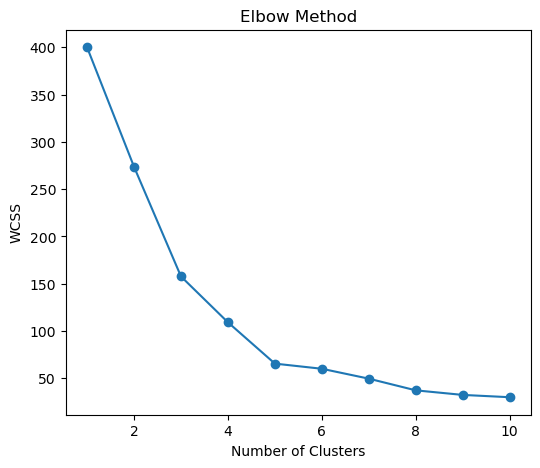

In [27]:
#plot the elbow  curve
plt.figure(figsize=(6,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [28]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [29]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [30]:
#Count customers in each cluster
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [31]:
#Calculate Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


K-Means Clustering

The Elbow Method was used to determine the optimal number of clusters. Based on the WCSS curve, 5 clusters were selected. K-Means clustering was then applied to segment customers according to Annual Income and Spending Score.

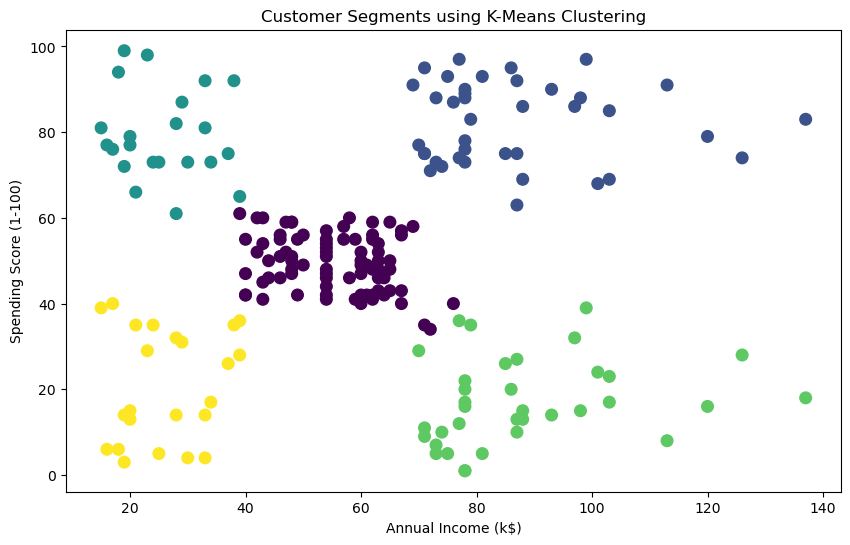

In [32]:
#Visualize Customer Segments
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=70
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments using K-Means Clustering')

plt.show()

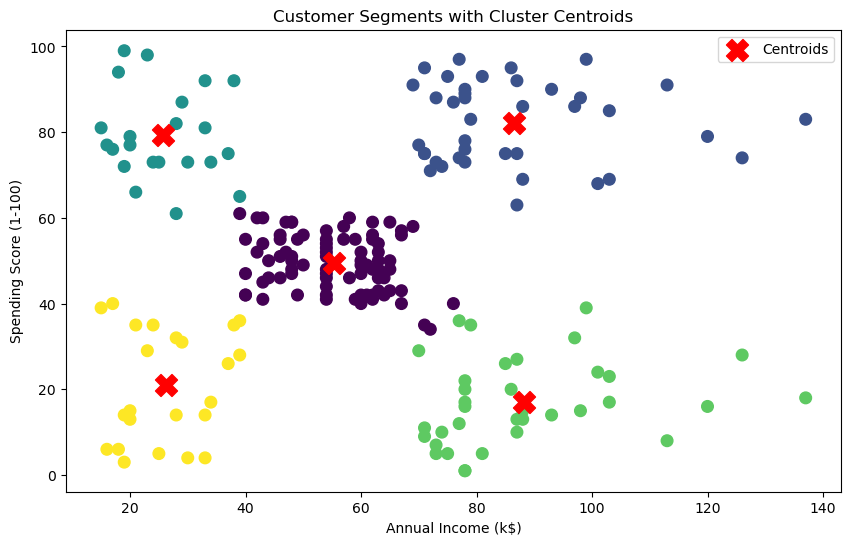

In [33]:
#Plot the cluster centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=70
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    color='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments with Cluster Centroids')

plt.legend()

plt.show()

### Observations

- Customers are grouped into five distinct segments based on their Annual Income and Spending Score.
- Each color represents a different customer segment.
- The red "X" markers indicate the centroid (center) of each cluster.
- Customers within the same cluster have similar purchasing behavior.
- These segments can help businesses design targeted marketing strategies.

In [34]:
#Calculate the average values for each cluster
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Number of Customers'})

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,42.716049,55.296296,49.518519,81
1,32.692308,86.538462,82.128205,39
2,25.272727,25.727273,79.363636,22
3,41.114286,88.200000,17.114286,35
4,45.217391,26.304348,20.913043,23


In [35]:
cluster_profile = cluster_profile.round(2)
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Number of Customers
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


## Cluster Profiling

### Cluster 0 - Average Customers
- Average age: 42.7 years
- Moderate annual income and spending score.
- Represents the largest customer segment.
- Recommendation: Maintain engagement through seasonal offers and loyalty rewards.

### Cluster 1 - Premium Customers
- High annual income and high spending score.
- Most valuable customers.
- Recommendation: Provide VIP memberships, exclusive products, and personalized services.

### Cluster 2 - Young High Spenders
- Young customers with lower income but high spending.
- Likely attracted to trendy and fashionable products.
- Recommendation: Promote new arrivals, limited editions, and social media campaigns.

### Cluster 3 - Careful Customers
- High annual income but low spending score.
- Have purchasing power but spend cautiously.
- Recommendation: Encourage purchases through targeted discounts and premium product recommendations.

### Cluster 4 - Budget Customers
- Low annual income and low spending score.
- Least active customer group.
- Recommendation: Offer affordable products, bundle deals, and promotional discounts.

In [37]:
#count customers in each cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_counts

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

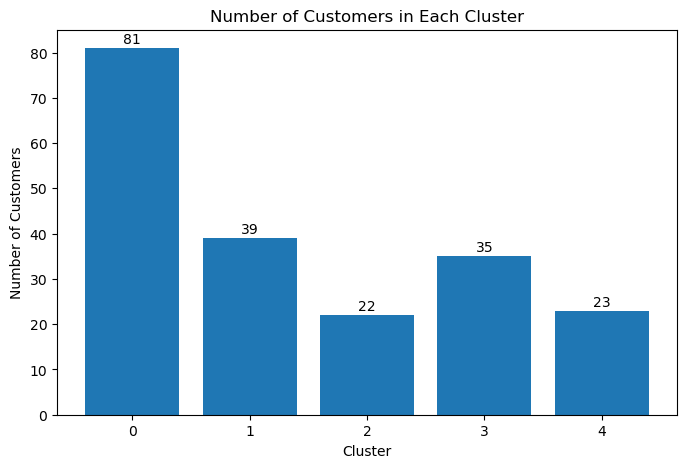

In [40]:
plt.figure(figsize=(8,5))

bars = plt.bar(cluster_counts.index,
               cluster_counts.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        int(bar.get_height()),
        ha='center'
    )

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(cluster_counts.index)

plt.show()

## Observation

- Cluster 0 contains the highest number of customers (81), making it the largest customer segment.
- Clusters 2 and 4 have the fewest customers, indicating niche customer groups.
- The variation in customer counts suggests that customer behavior is not evenly distributed across all segments.
- Businesses can prioritize marketing strategies based on the size and characteristics of each customer segment.

# Business Insights

## Insight 1
The largest customer segment consists of average-income and average-spending customers (Cluster 0). This indicates that most customers have balanced purchasing behavior and represent a stable source of revenue.

## Insight 2
Cluster 1 contains high-income customers with high spending scores. Although this segment is smaller, it contributes significantly to business revenue and should be retained through premium services.

## Insight 3
Cluster 3 consists of customers with high income but low spending scores. These customers have strong purchasing power but are not spending much, presenting an opportunity for targeted marketing campaigns.

## Insight 4
Cluster 2 contains young customers with relatively low income but high spending scores. These customers are likely attracted to trendy products and can become loyal customers if engaged effectively.

## Insight 5
Cluster 4 includes customers with both low income and low spending scores. This group is price-sensitive and responds better to discounts and budget-friendly offers.

# Marketing Recommendations

### 1. Reward Premium Customers
Provide VIP memberships, exclusive discounts, early access to new products, and personalized recommendations for Cluster 1 to improve customer retention.

### 2. Increase Spending of Careful Customers
Launch personalized email campaigns, limited-time offers, and product bundles for Cluster 3 to encourage higher spending.

### 3. Retain Young High Spenders
Target Cluster 2 through social media marketing, influencer collaborations, and loyalty programs to build long-term customer relationships.

### 4. Engage Average Customers
Offer seasonal promotions and reward points to maintain the purchasing behavior of Cluster 0.

### 5. Attract Budget Customers
Provide affordable product bundles, cashback offers, and discount coupons to increase purchases from Cluster 4.